In [19]:
import seaborn as sns
import pandas as pd
import numpy as np

df = pd.read_csv("../datasets/generated/penguins_fake_real.CSV")
df = df.drop('Unnamed: 0', axis=1)
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex,source
0,Adelie,Dream,39.5,16.7,178.0,3250.0,FEMALE,real
1,Gentoo,Biscoe,46.9,14.6,222.0,4875.0,FEMALE,real
2,Adelie,Torgersen,42.1,19.1,195.0,4000.0,MALE,real
3,Chinstrap,Dream,49.8,17.3,198.0,3675.0,FEMALE,real
4,Adelie,Biscoe,41.1,18.2,192.0,4050.0,MALE,real


<AxesSubplot:xlabel='culmen_length_mm', ylabel='flipper_length_mm'>

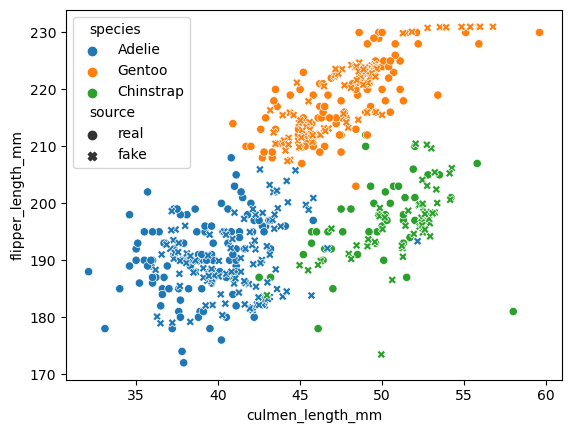

In [20]:
sns.scatterplot(data=df, x="culmen_length_mm", y="flipper_length_mm", hue="species", style="source")  

In [21]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Berechnete Wasserstein-Distanzen (skaliert):
  culmen_length_mm: 0.2894
  culmen_depth_mm: 0.0882
  flipper_length_mm: 0.0685
  body_mass_g: 0.1858


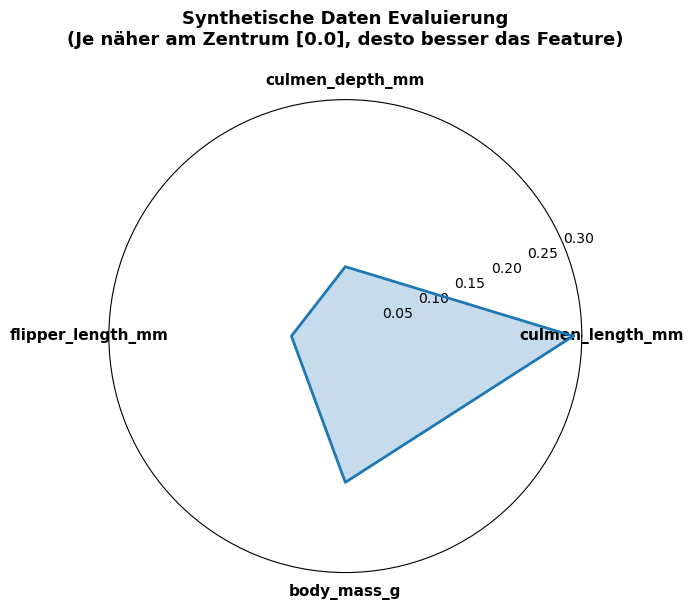

In [22]:
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
if 'id' in numerical_cols: numerical_cols.remove('id') # optional

# 3. DATEN SKALIEREN (Essentiell für den gemeinsamen Radialplot!)
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Splitten in echten und synthetischen Teil anhand der Status-Spalte
df_real = df_scaled[df_scaled['source'] == 'real']
df_fake = df_scaled[df_scaled['source'] == 'fake']

# 4. Wasserstein-Distanz pro Feature berechnen
wd_results = {}
for col in numerical_cols:
    wd = wasserstein_distance(df_real[col], df_fake[col])
    wd_results[col] = wd

print("Berechnete Wasserstein-Distanzen (skaliert):")
for col, val in wd_results.items():
    print(f"  {col}: {val:.4f}")

# 5. RADIALPLOT ERSTELLEN
labels = list(wd_results.keys())
stats = list(wd_results.values())

# Für ein Radar-Chart müssen wir den Kreis schließen 
# (der letzte Punkt muss identisch mit dem ersten sein)
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
stats += stats[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

# Zeichne die Linie und fülle die Fläche darunter
ax.plot(angles, stats, color='#1f77b4', linewidth=2, linestyle='solid', label='Wasserstein-Distanz')
ax.fill(angles, stats, color='#1f77b4', alpha=0.25)

# Beschriftung der Zacken/Sektoren (Features)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')

# Styling des Netzes
ax.grid(color='grey', linestyle='--', linewidth=0.5)

# Titel hinzufügen
plt.title("Synthetische Daten Evaluierung\n(Je näher am Zentrum [0.0], desto besser das Feature)", 
          size=13, weight='bold', pad=20)

plt.tight_layout()
plt.show()

Cooler wäre 

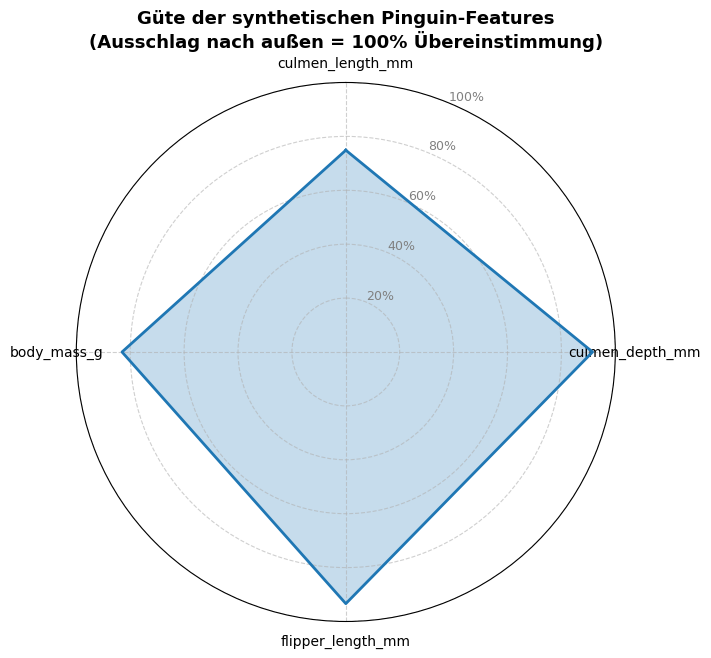

In [24]:
# 1. Wasserstein-Distanz & Score berechnen
wd_scores = {}
for col in numerical_cols:
    wd = wasserstein_distance(df_real[col], df_fake[col])
    # Umwandlung: 0 Distanz -> 1.0 (100%), große Distanz -> geht gegen 0
    wd_scores[col] = np.exp(-wd)

# Vorbereitung für den Radar-Chart (Kreisplot)
labels = list(wd_scores.keys())
stats = list(wd_scores.values())

# Der Kreis muss mathematisch geschlossen werden (erster Punkt = letzter Punkt)
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
stats += stats[:1]
angles += angles[:1]
labels_closed = labels + [labels[0]] # Für die Platzierung der Texte

# 2. Plot erstellen
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(projection='polar'))

# Hintergrund-Netz stylen
ax.set_theta_offset(np.pi / 2) # Startet oben auf 12 Uhr
ax.set_theta_direction(-1)     # Geht im Uhrzeigersinn

# Features an den äußeren Enden beschriften
ax.set_thetagrids(np.degrees(angles[:-1]), labels)

# Die blaue Fläche zeichnen
ax.plot(angles, stats, color='#1f77b4', linewidth=2, linestyle='solid')
ax.fill(angles, stats, color='#1f77b4', alpha=0.25)

# --- HIER SIND DIE ANPASSUNGEN FÜR DEINE FOLIE ---
ax.set_ylim(0, 1.0) # Skala fest auf 0% bis 100% setzen

# Ring-Beschriftungen hinzufügen
ax.set_rticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["20%", "40%", "60%", "80%", "100%"], color="grey", size=9)
ax.grid(True, linestyle='--', alpha=0.6)

# Titel verpassen
plt.title("Güte der synthetischen Pinguin-Features\n(Ausschlag nach außen = 100% Übereinstimmung)", 
          size=13, weight='bold', pad=25)

# Plot anzeigen
plt.show()